In [15]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set display options for Jupyter
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [16]:
# Cell 2: Load data
df = pd.read_excel('ai_job_trends_dataset.xlsx', sheet_name='in')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (30000, 13)


,Job Title,Industry,Job Status,AI Impact Level,Median Salary (USD),Required Education,Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Location,Gender Diversity (%)
0,Investment analyst,IT,Increasing,Moderate,42109.76,Masterâ€™s Degree,5,1515,6342,55.96,28.28,UK,44.63
1,"Journalist, newspaper",Manufacturing,Increasing,Moderate,132298.57,Masterâ€™s Degree,15,1243,6205,16.81,89.71,USA,66.39
2,Financial planner,Finance,Increasing,Low,143279.19,Bachelorâ€™s Degree,4,3338,1154,91.82,72.97,Canada,41.13
3,Legal secretary,Healthcare,Increasing,High,97576.13,Associate Degree,15,7173,4060,1.89,99.94,Australia,65.76
4,Aeronautical engineer,IT,Increasing,Low,60956.63,Masterâ€™s Degree,13,5944,7396,53.76,37.65,Germany,72.57


In [17]:
# Cell 3: Quick overview
print("Columns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# Summary statistics
df.describe(include='all').T

Columns: ['Job Title', 'Industry', 'Job Status', 'AI Impact Level', 'Median Salary (USD)', 'Required Education', 'Experience Required (Years)', 'Job Openings (2024)', 'Projected Openings (2030)', 'Remote Work Ratio (%)', 'Automation Risk (%)', 'Location', 'Gender Diversity (%)']

Data types:
 Job Title                       object
Industry                        object
Job Status                      object
AI Impact Level                 object
Median Salary (USD)            float64
Required Education              object
Experience Required (Years)      int64
Job Openings (2024)              int64
Projected Openings (2030)        int64
Remote Work Ratio (%)          float64
Automation Risk (%)            float64
Location                        object
Gender Diversity (%)           float64
dtype: object

Missing values:
 Job Title                      0
Industry                       0
Job Status                     0
AI Impact Level                0
Median Salary (USD)            0
Re

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Job Title,30000,639,"Surveyor, insurance",75,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Industry,30000,8,Entertainment,3895,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job Status,30000,2,Increasing,15136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AI Impact Level,30000,3,Moderate,10042,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Median Salary (USD),30000.0,NaN,NaN,NaN,90119.965639,34412.013953,30001.86,60500.7025,90274.115,119454.71,149998.5
Required Education,30000,5,Bachelorâ€™s Degree,6146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience Required (Years),30000.0,NaN,NaN,NaN,10.051433,6.060678,0.0,5.0,10.0,15.0,20.0
Job Openings (2024),30000.0,NaN,NaN,NaN,5039.640833,2861.009654,100.0,2570.0,5034.0,7527.0,10000.0
Projected Openings (2030),30000.0,NaN,NaN,NaN,5074.2181,2866.550722,100.0,2586.75,5106.5,7573.0,10000.0
Remote Work Ratio (%),30000.0,NaN,NaN,NaN,49.836431,28.966688,0.0,24.57,49.57,75.1,100.0


In [18]:
# Cell 4: Clean categorical text
df['Required Education'] = df['Required Education'].str.replace('â€™', "'", regex=False)
print("Unique Education levels after cleaning:", df['Required Education'].unique())

Unique Education levels after cleaning: ["Master's Degree" "Bachelor's Degree" 'Associate Degree' 'High School'
 'PhD']


In [19]:
# Cell 5: Drop Job Title (high cardinality)
df = df.drop(columns=['Job Title'])
print("Shape after dropping Job Title:", df.shape)

Shape after dropping Job Title: (30000, 12)


In [20]:
# Cell 6: Feature Engineering
# 1. Job growth rate (2024 → 2030)
df['Job_Growth_Rate'] = ((df['Projected Openings (2030)'] - df['Job Openings (2024)']) 
                         / df['Job Openings (2024)'].replace(0, np.nan)) * 100

# 2. Log transform salary (helps with skewed distributions)
df['Log_Median_Salary'] = np.log1p(df['Median Salary (USD)'])

# 3. Experience category (optional but useful)
df['Experience_Category'] = pd.cut(df['Experience Required (Years)'], 
                                   bins=[-1, 2, 5, 10, 20, 100], 
                                   labels=['0-2', '3-5', '6-10', '11-20', '20+'])

print(df[['Job_Growth_Rate', 'Log_Median_Salary', 'Experience_Category']].head())

   Job_Growth_Rate  Log_Median_Salary Experience_Category
0       318.613861          10.648059                 3-5
1       399.195495          11.792824               11-20
2       -65.428400          11.872557                 3-5
3       -43.398857          11.488398               11-20
4        24.427995          11.017934               11-20


In [21]:
# Cell 7: Define X and y
target = 'AI Impact Level'          # ← Your main target (classification)
X = df.drop(columns=[target, 'Automation Risk (%)'])   # drop numerical alternative target too
y = df[target]

print("Features shape:", X.shape)
print("Target classes:\n", y.value_counts())

Features shape: (30000, 13)
Target classes:
 AI Impact Level
Moderate    10042
High        10005
Low          9953
Name: count, dtype: int64


In [22]:
# Cell 8: Encoding
# One-hot encode low-cardinality categoricals
categorical_cols = ['Industry', 'Job Status', 'Required Education', 'Location', 'Experience_Category']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Label encode target (for classification)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Encoded classes:", dict(zip(le.classes_, le.transform(le.classes_))))

Encoded classes: {'High': np.int64(0), 'Low': np.int64(1), 'Moderate': np.int64(2)}


In [23]:
# Cell 9: Scale numerical features
numerical_cols = ['Median Salary (USD)', 'Experience Required (Years)', 
                  'Job Openings (2024)', 'Projected Openings (2030)', 
                  'Remote Work Ratio (%)', 'Gender Diversity (%)',
                  'Job_Growth_Rate', 'Log_Median_Salary']

scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

In [24]:
# Cell 10: Final split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (24000, 31)
Test set: (6000, 31)


In [25]:
# Cell 11: Save preprocessed files
pd.DataFrame(X_train).to_csv('X_train_preprocessed.csv', index=False)
pd.DataFrame(X_test).to_csv('X_test_preprocessed.csv', index=False)
pd.Series(y_train).to_csv('y_train.csv', index=False)
pd.Series(y_test).to_csv('y_test.csv', index=False)
print("Preprocessed files saved!")

Preprocessed files saved!


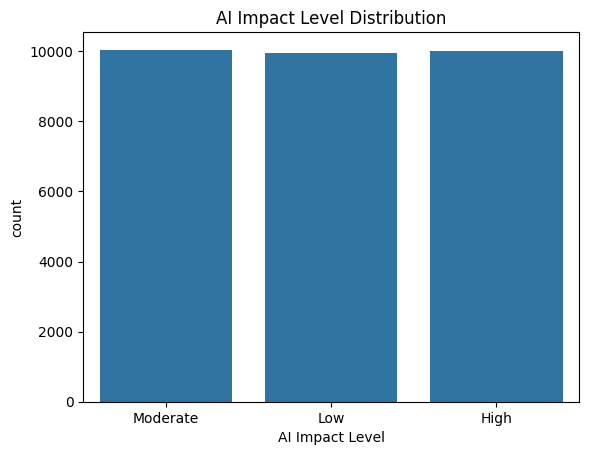

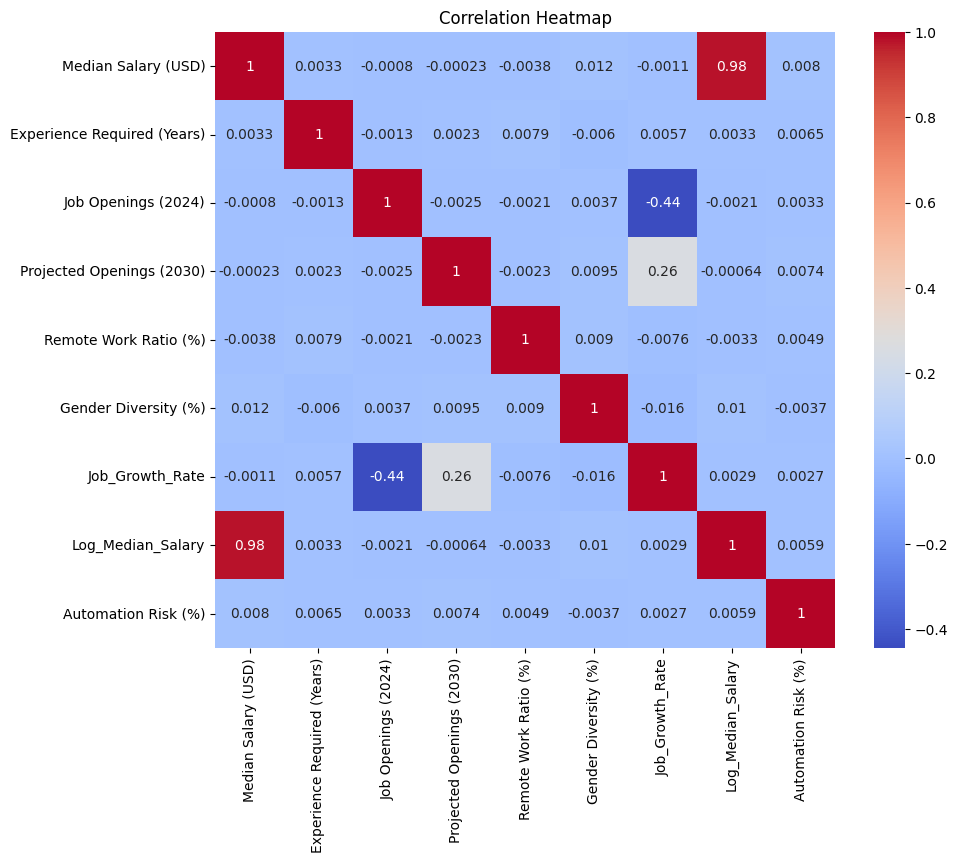

In [26]:
# EDA: Target distribution
sns.countplot(x=y)
plt.title('AI Impact Level Distribution')
plt.show()

# Correlation heatmap (numerical features only)
plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_cols + ['Automation Risk (%)']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()